# Rotation-based RHESSI-IRIS alignment

This notebook reproduces the RHESSI-IRIS case study from the MSc thesis. An IRIS frame is first corrected with the IRIS-AIA alignment parameters. The RHESSI image is then reprojected onto the corrected IRIS grid and rotated around solar disk center. The best angle maximizes the Pearson correlation coefficient at zero translational shift.

The observational FITS files are expected to be available locally.

In [1]:
import copy
from pathlib import Path

import astropy.units as u
import irisreader as ir
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.lines import Line2D
from reproject import reproject_interp
from scipy.stats import pearsonr
from sunpy.coordinates import frames
from sunpy.map import Map
from sunpy.map.header_helper import make_fitswcs_header

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "utils.py").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "utils.py").is_file():
    raise FileNotFoundError("Run this notebook from the repository root or examples directory.")

In [2]:
def crop_to_reference(reference_map, footprint_map):
    """Crop a reference map to the footprint of another map."""
    ny, nx = footprint_map.data.shape
    bottom_left = footprint_map.pixel_to_world(0 * u.pix, 0 * u.pix)
    top_right = footprint_map.pixel_to_world((nx - 1) * u.pix, (ny - 1) * u.pix)
    return reference_map.submap(bottom_left=bottom_left, top_right=top_right)


def normalize_data(data, low=0, high=100):
    """Percentile-normalize a 2D image to [0, 1]."""
    data = np.array(data, dtype=float, copy=True)
    finite = np.isfinite(data)
    if not np.any(finite):
        return np.zeros_like(data)

    vmin, vmax = np.percentile(data[finite], (low, high))
    if np.isclose(vmax, vmin):
        normalized = np.zeros_like(data)
    else:
        normalized = np.clip((data - vmin) / (vmax - vmin), 0, 1)
    normalized[~np.isfinite(normalized)] = 0
    return normalized


def rotate_about_sun_center(map_, angle_deg):
    """Rotate a SunPy map around solar disk center while retaining its field of view."""
    sun_center = SkyCoord(
        0 * u.arcsec,
        0 * u.arcsec,
        frame=frames.Helioprojective(
            obstime=map_.date,
            observer=map_.observer_coordinate,
        ),
    )
    x_center, y_center = map_.world_to_pixel(sun_center)
    reference_pixel = u.Quantity([x_center, y_center])
    scale = u.Quantity(map_.wcs.wcs.cdelt, u.deg / u.pix)

    header = make_fitswcs_header(
        map_.data.shape,
        sun_center,
        scale=scale,
        rotation_angle=angle_deg * u.deg,
        reference_pixel=reference_pixel,
    )
    output_wcs = WCS(header)
    rotated, footprint = reproject_interp(
        (map_.data, map_.wcs),
        output_wcs,
        shape_out=map_.data.shape,
        order="bilinear",
    )
    rotated[footprint == 0] = np.nan
    return Map(rotated, header)

In [3]:
def pearson_correlation(reference, target, mask=None):
    """Calculate Pearson correlation over valid, optionally masked pixels."""
    valid = np.isfinite(reference) & np.isfinite(target)
    if mask is not None:
        valid &= np.asarray(mask, dtype=bool)
    if np.sum(valid) < 2:
        return np.nan

    reference_values = np.asarray(reference)[valid]
    target_values = np.asarray(target)[valid]
    if np.std(reference_values) == 0 or np.std(target_values) == 0:
        return np.nan
    return pearsonr(reference_values, target_values).statistic


def find_best_rotation(reference_map, rhessi_map, angle_grid, mask_threshold):
    """Select the solar-center rotation with the largest zero-shift correlation."""
    cropped_reference = crop_to_reference(reference_map, rhessi_map)
    rhessi_reprojected = rhessi_map.reproject_to(cropped_reference.wcs)
    normalized_reference = normalize_data(cropped_reference.data)

    scores = []
    best_angle = None
    best_score = -np.inf
    best_rotated = None

    for angle in angle_grid:
        rotated = rotate_about_sun_center(rhessi_reprojected, angle)
        normalized_rhessi = normalize_data(rotated.data)
        mask = normalized_rhessi >= mask_threshold
        score = pearson_correlation(normalized_reference, normalized_rhessi, mask)
        scores.append((angle, score))

        if np.isfinite(score) and score > best_score:
            best_angle = float(angle)
            best_score = float(score)
            best_rotated = rotated

    if best_rotated is None:
        raise ValueError("No finite correlation was found; review the input maps and threshold.")

    return {
        "reference": cropped_reference,
        "rhessi_original": rhessi_reprojected,
        "rhessi_aligned": best_rotated,
        "best_angle": best_angle,
        "best_score": best_score,
        "scores": np.asarray(scores),
    }

In [4]:
def plot_alignment(result, levels=(0.6, 0.7, 0.9)):
    """Overlay original and rotation-corrected RHESSI contours."""
    reference = result["reference"]
    normalized_reference = Map(normalize_data(reference.data), reference.meta)
    original = normalize_data(result["rhessi_original"].data)
    aligned = normalize_data(result["rhessi_aligned"].data)

    figure = plt.figure(figsize=(8, 7))
    axis = figure.add_subplot(projection=reference)
    normalized_reference.plot(axes=axis, cmap="gray_r")
    axis.contour(original, levels=levels, colors="dodgerblue", linewidths=1)
    axis.contour(aligned, levels=levels, colors="red", linewidths=1)
    axis.legend(handles=[
        Line2D([0], [0], color="red", label=f"RHESSI aligned ({result['best_angle']:+.2f} deg)"),
        Line2D([0], [0], color="dodgerblue", label="RHESSI original"),
    ])
    return figure


def plot_score_curve(result):
    """Show the correlation coefficient evaluated for each trial angle."""
    angles, scores = result["scores"].T
    figure, axis = plt.subplots(figsize=(7, 4))
    axis.plot(angles, scores)
    axis.axvline(result["best_angle"], color="red", linestyle="--",
                label=f"best angle = {result['best_angle']:+.2f} deg")
    axis.set(xlabel="Rotation angle (deg)", ylabel="Pearson correlation coefficient")
    axis.legend()
    return figure

In [5]:
def apply_iris_aia_alignment(iris_sji, frame, dx, dy, theta_deg):
    """Apply the fitted IR-AIA translation and rotation to one IRIS SJI frame."""
    data = iris_sji.get_image_step(frame)
    header_values = copy.deepcopy(iris_sji.headers[frame])

    header_values["XCENIX"] += float(dx)
    header_values["YCENIX"] += float(dy)
    header_values["XCEN"] = header_values["XCENIX"]
    header_values["YCEN"] = header_values["YCENIX"]
    header_values["CRVAL1"] = header_values["XCENIX"]
    header_values["CRVAL2"] = header_values["YCENIX"]

    theta = np.deg2rad(theta_deg)
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta),  np.cos(theta)]])
    old_pc = np.array([
        [header_values.get("PC1_1", 1.0), header_values.get("PC1_2", 0.0)],
        [header_values.get("PC2_1", 0.0), header_values.get("PC2_2", 1.0)],
    ])
    new_pc = rotation @ old_pc
    header_values["PC1_1"], header_values["PC1_2"] = map(float, new_pc[0])
    header_values["PC2_1"], header_values["PC2_2"] = map(float, new_pc[1])
    if "CROTA2" in header_values:
        header_values["CROTA2"] = float(header_values["CROTA2"]) + float(theta_deg)

    header = fits.Header()
    for key, value in header_values.items():
        if key == "NAXIS3" or value is None:
            continue
        header[key] = value.replace("\n", " ") if isinstance(value, str) else value
    return Map(data, header)


## RHESSI to aligned IRIS - 29 March 2014

The IRIS frame is first corrected with the IRIS-AIA parameters from the thesis run. The values below are the fitted corrections reported for IRIS frame 499 and are treated as fixed inputs to this case study; they are not re-estimated in this notebook. The RHESSI rotation is then optimized against that corrected frame.

Best angle: -0.150 deg
Pearson correlation: 0.579961


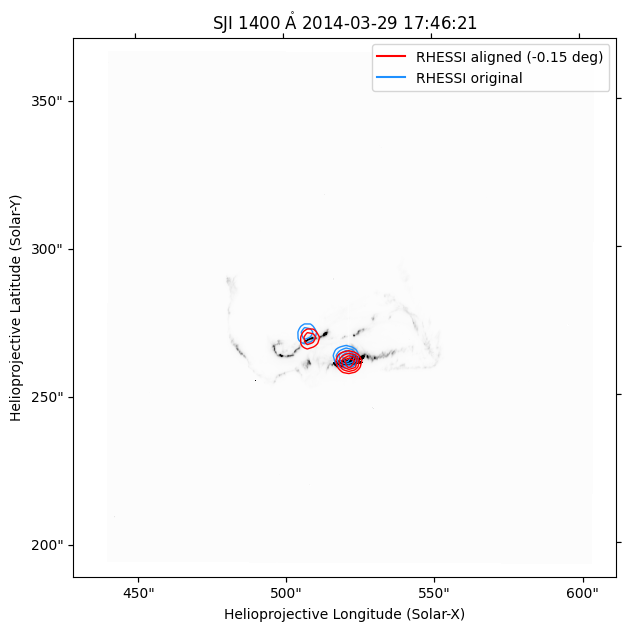

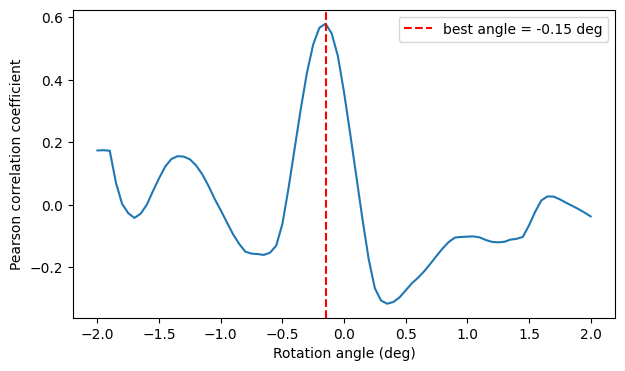

In [6]:
DATA_DIR = PROJECT_ROOT / "data"
IRIS_OBSERVATION = DATA_DIR / "20140329_140938_3860258481"
RHESSI_2014 = DATA_DIR / "hsi_image_20140329_174613.fits"

IRIS_FRAME = 499
# IRIS-AIA corrections for this frame from the thesis alignment results
IRIS_DX_ARCSEC = 1.068359
IRIS_DY_ARCSEC = -0.060547
IRIS_ROTATION_DEG = 0.3

observation = ir.observation(str(IRIS_OBSERVATION))
iris_sji = observation.sji[0]
aligned_iris_map = apply_iris_aia_alignment(
    iris_sji, IRIS_FRAME, IRIS_DX_ARCSEC, IRIS_DY_ARCSEC, IRIS_ROTATION_DEG
)
rhessi_2014_map = Map(RHESSI_2014)

result_2014 = find_best_rotation(
    aligned_iris_map, rhessi_2014_map,
    angle_grid=np.arange(-2.0, 2.01, 0.05),
    mask_threshold=0.5,
)
print(f"Best angle: {result_2014['best_angle']:+.3f} deg")
print(f"Pearson correlation: {result_2014['best_score']:.6f}")
plot_alignment(result_2014, levels=(0.6, 0.7, 0.8, 0.9))
plot_score_curve(result_2014);
